In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

### Get AQI Data

In [4]:
df = pd.read_csv("data/aqi_data.csv")
df

,Date,Source,Site ID,POC,Daily Max 8-hour Ozone Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2021,AQS,60730001,1,0.040,ppm,37,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
1,01/02/2021,AQS,60730001,1,0.038,ppm,35,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
2,01/03/2021,AQS,60730001,1,0.041,ppm,38,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
3,01/04/2021,AQS,60730001,1,0.039,ppm,36,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
4,01/05/2021,AQS,60730001,1,0.034,ppm,31,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14484,12/05/2025,AirNow,60739991,1,0.046,ppm,43,La Posta Band of Indians,24,100.0,...,Ozone,NaN,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.725189,-116.364410
14485,12/06/2025,AirNow,60739991,1,0.047,ppm,44,La Posta Band of Indians,24,100.0,...,Ozone,NaN,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.725189,-116.364410
14486,12/07/2025,AirNow,60739991,1,0.042,ppm,39,La Posta Band of Indians,24,100.0,...,Ozone,NaN,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.725189,-116.364410
14487,12/08/2025,AirNow,60739991,1,0.045,ppm,42,La Posta Band of Indians,24,100.0,...,Ozone,NaN,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.725189,-116.364410


In [6]:
df.describe()

,Site ID,POC,Daily Max 8-hour Ozone Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,1.448900e+04,14489.0,14489.000000,14489.000000,14489.000000,14489.000000,14489.0,12315.000000,14489.0,14489.0,14489.0,14489.000000,14489.000000
mean,6.073153e+07,1.0,0.044117,42.953965,17.634343,97.703430,44201.0,52.310597,41740.0,6.0,73.0,32.860506,-117.008677
std,2.288300e+03,0.0,0.010467,15.529692,2.651911,6.411864,0.0,13.573371,0.0,0.0,0.0,0.251168,0.241643
min,6.073000e+07,1.0,0.000000,0.000000,13.000000,71.000000,44201.0,47.000000,41740.0,6.0,73.0,32.578165,-117.396249
25%,6.073101e+07,1.0,0.038000,35.000000,17.000000,100.000000,44201.0,47.000000,41740.0,6.0,73.0,32.710177,-117.123964
50%,6.073102e+07,1.0,0.044000,41.000000,17.000000,100.000000,44201.0,47.000000,41740.0,6.0,73.0,32.789565,-117.059088
75%,6.073103e+07,1.0,0.050000,46.000000,17.000000,100.000000,44201.0,47.000000,41740.0,6.0,73.0,32.845709,-116.921374
max,6.073999e+07,1.0,0.090000,161.000000,24.000000,100.000000,44201.0,87.000000,41740.0,6.0,73.0,33.362593,-116.364410


In [25]:
df['Local Site Name'].unique()


array(['Chula Vista', 'Alpine', 'Camp Pendleton', 'Donovan',
       'San Diego - Kearny Villa Rd.',
       'El Cajon - Lexington Elementary School',
       'San Diego - Sherman Elementary School', 'Pala Airpad',
       'La Posta Band of Indians'], dtype=object)

In [23]:
df['Site ID'].nunique()

9

In [24]:
df['CBSA Name'].unique()

array(['San Diego-Carlsbad, CA'], dtype=object)

In [26]:
df.isna().sum()

Date                                       0
Source                                     0
Site ID                                    0
POC                                        0
Daily Max 8-hour Ozone Concentration       0
Units                                      0
Daily AQI Value                            0
Local Site Name                            0
Daily Obs Count                            0
Percent Complete                           0
AQS Parameter Code                         0
AQS Parameter Description                  0
Method Code                             2174
CBSA Code                                  0
CBSA Name                                  0
State FIPS Code                            0
State                                      0
County FIPS Code                           0
County                                     0
Site Latitude                              0
Site Longitude                             0
dtype: int64

In [27]:
df.value_counts('Local Site Name')

Local Site Name
San Diego - Sherman Elementary School     1766
Alpine                                    1761
San Diego - Kearny Villa Rd.              1759
Donovan                                   1747
Camp Pendleton                            1681
Pala Airpad                               1635
El Cajon - Lexington Elementary School    1609
Chula Vista                               1563
La Posta Band of Indians                   968
Name: count, dtype: int64

In [31]:
df.value_counts('Date')

Date
04/05/2024    9
04/24/2023    9
04/21/2023    9
04/21/2024    9
04/22/2023    9
             ..
08/20/2025    5
09/27/2025    5
09/22/2022    5
01/25/2021    5
09/24/2021    4
Name: count, Length: 1800, dtype: int64

In [33]:
df['Date'] = pd.to_datetime(df['Date'])

In [34]:
df.groupby("Local Site Name").resample("D", on="Date")["Daily AQI Value"].mean()

Local Site Name                        Date      
Alpine                                 2021-01-01    39.0
                                       2021-01-02    42.0
                                       2021-01-03    42.0
                                       2021-01-04    40.0
                                       2021-01-05    40.0
                                                     ... 
San Diego - Sherman Elementary School  2025-12-05    30.0
                                       2025-12-06    35.0
                                       2025-12-07    34.0
                                       2025-12-08    34.0
                                       2025-12-09    25.0
Name: Daily AQI Value, Length: 15316, dtype: float64

In [37]:
df.columns

Index(['Date', 'Source', 'Site ID', 'POC',
       'Daily Max 8-hour Ozone Concentration', 'Units', 'Daily AQI Value',
       'Local Site Name', 'Daily Obs Count', 'Percent Complete',
       'AQS Parameter Code', 'AQS Parameter Description', 'Method Code',
       'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')

In [38]:
stations_per_day = df.groupby('Date')['Local Site Name'].nunique()
stations_per_day.describe()

count    1800.000000
mean        8.049444
std         0.850269
min         4.000000
25%         8.000000
50%         8.000000
75%         9.000000
max         9.000000
Name: Local Site Name, dtype: float64

In [39]:
pivot = df.pivot_table(
    index='Date',
    columns='Local Site Name',
    values='Daily AQI Value'
)

In [42]:
pivot['County Mean AQI'] = pivot.mean(axis=1)


NameError: name 'plt' is not defined

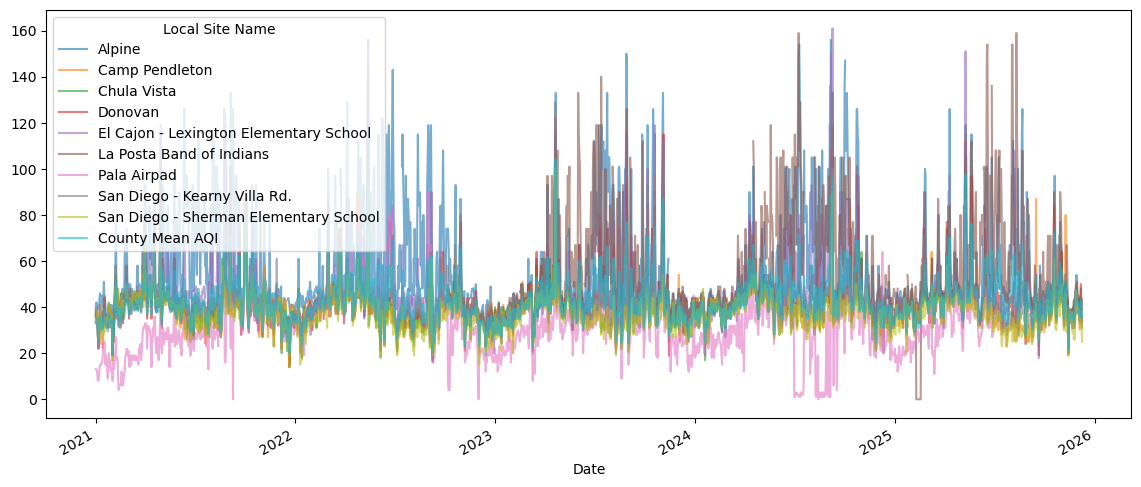

In [43]:
pivot.plot(figsize=(14,6), alpha=0.6)
plt.title("Daily AQI for All Monitoring Stations (2021–2025)")
plt.ylabel("AQI")

### Mean AQI By Month

<Axes: xlabel='Month'>

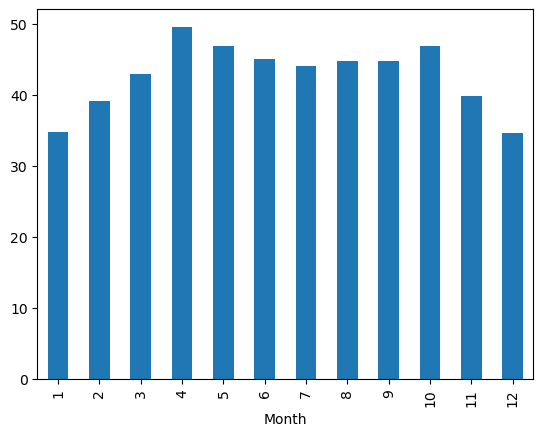

In [44]:
pivot['Month'] = pivot.index.month
pivot.groupby('Month')['County Mean AQI'].mean().plot(kind='bar')


In [45]:
pivot['7d'] = pivot['County Mean AQI'].rolling(7).mean()
pivot['30d'] = pivot['County Mean AQI'].rolling(30).mean()


In [46]:
heavy_days = pivot[pivot['County Mean AQI'] > 100]


In [49]:
coastal_stations = [
    "Chula Vista",
    "Camp Pendleton",
    "San Diego - Sherman Elementary School"
]


urban_stations = [
    "San Diego - Kearny Villa Rd.",
    "El Cajon - Lexington Elementary School",
    "Donovan"
]

inland_stations = [
    "Alpine",
    "Pala Airpad",
    "La Posta Band of Indians"
]

coastal = pivot[coastal_stations].mean(axis=1)
inland  = pivot[inland_stations].mean(axis=1)

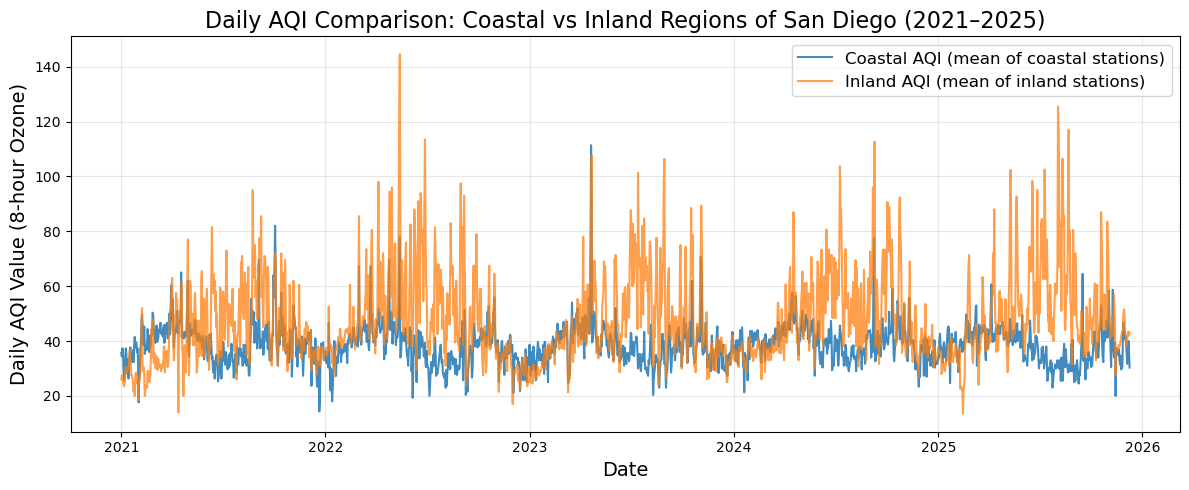

In [56]:
coastal_smooth = coastal.rolling(window=7, center=True).mean()
inland_smooth = inland.rolling(window=7, center=True).mean()

plt.figure(figsize=(12,5))

plt.plot(coastal, label="Coastal AQI (mean of coastal stations)", alpha=0.85)
plt.plot(inland, label="Inland AQI (mean of inland stations)", alpha=0.75)

plt.title("Daily AQI Comparison: Coastal vs Inland Regions of San Diego (2021–2025)", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Daily AQI Value (8-hour Ozone)", fontsize=14)

plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Coastal vs Urban Analysis (Including urban stations)

In [59]:
coastal_urban_stations = [
    'Chula Vista',
    'Camp Pendleton',
    'San Diego - Sherman Elementary School'
]

inland_urban_stations = [
    'Alpine',
    'Pala Airpad',
    'La Posta Band of Indians',
    'El Cajon - Lexington Elementary School',
    'Donovan'
]

coastal_urban = pivot[coastal_urban_stations].mean(axis=1)
inland_urban = pivot[inland_urban_stations].mean(axis=1)

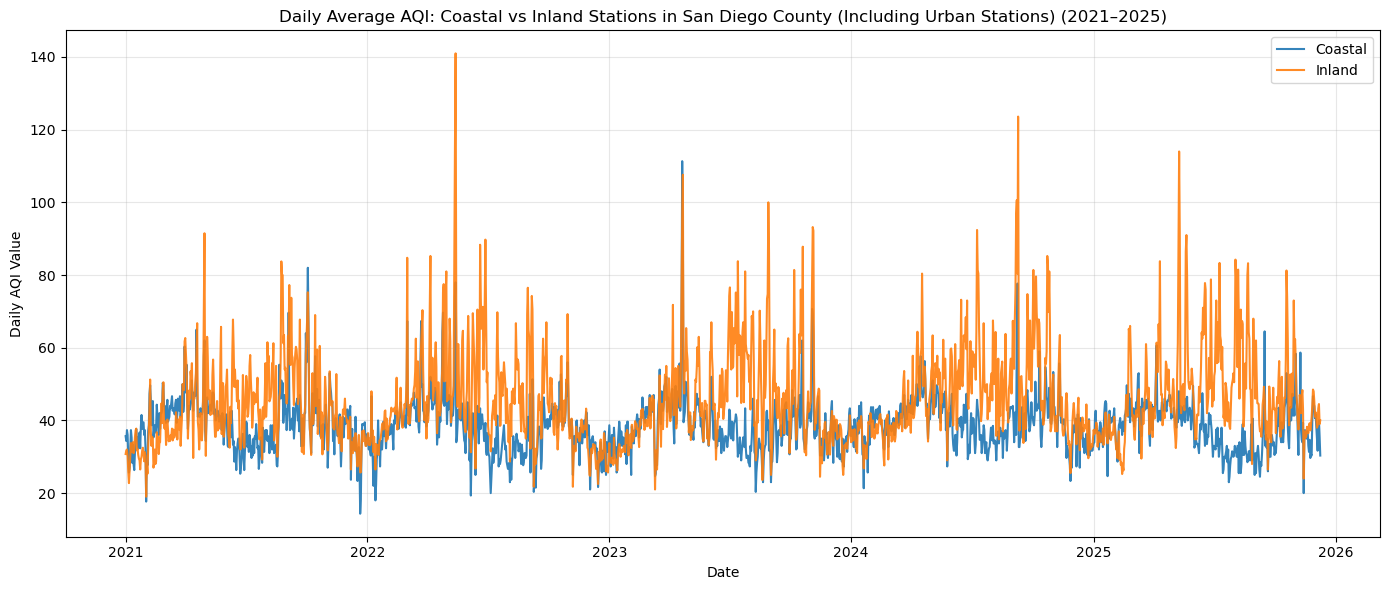

In [60]:
plt.figure(figsize=(14,6))
plt.plot(coastal_urban.index, coastal_urban, label="Coastal", alpha=0.9)
plt.plot(inland_urban.index, inland_urban, label="Inland", alpha=0.9)

plt.title("Daily Average AQI: Coastal vs Inland Stations in San Diego County (Including Urban Stations) (2021–2025)")
plt.xlabel("Date")
plt.ylabel("Daily AQI Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
pivot.isna().sum().sort_values().drop(['County Mean AQI', 'Month', '7d', '30d'])

Local Site Name
San Diego - Sherman Elementary School      34
Alpine                                     39
San Diego - Kearny Villa Rd.               41
Donovan                                    53
Camp Pendleton                            119
Pala Airpad                               165
El Cajon - Lexington Elementary School    191
Chula Vista                               237
La Posta Band of Indians                  832
dtype: int64

In [66]:
monthly = pivot.resample('M').mean()
monthly = monthly.drop(columns=['County Mean AQI'])

C:\Users\diego\AppData\Local\Temp\ipykernel_8288\2948661079.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = pivot.resample('M').mean()


### Get Asthma Data

In [69]:
asthma = pd.read_csv('data/asthma.csv')

In [72]:
asthma.describe()

,Year,Zip_Code,Number_of_Asthma_ED_Visits,Age_Adjusted_Rate_of_Asthma_ED_V
count,12544.000000,12544.000000,12544.000000,12544.000000
mean,2017.927774,93220.995934,131.184471,40.267777
std,3.163016,1787.719672,133.187384,28.389523
min,2013.000000,90001.000000,12.000000,2.900000
25%,2015.000000,91915.000000,41.000000,21.400000
50%,2018.000000,93223.000000,85.000000,33.200000
75%,2021.000000,94931.000000,176.000000,50.700000
max,2023.000000,96161.000000,1130.000000,669.300000


In [76]:
asthma = asthma[(asthma['Year'] >= 2021) & (asthma['County'] == 'San Diego')]

In [81]:
asthma["Zip_Code"] = asthma["Zip_Code"].astype(str).str.zfill(5)


C:\Users\diego\AppData\Local\Temp\ipykernel_8288\2292992464.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  asthma["Zip_Code"] = asthma["Zip_Code"].astype(str).str.zfill(5)


In [82]:
asthma["Zip_Code"].unique()


array(['91901', '91902', '91906', '91910', '91911', '91913', '91914',
       '91915', '91932', '91935', '91941', '91942', '91945', '91950',
       '91977', '91978', '92008', '92009', '92010', '92011', '92019',
       '92020', '92021', '92024', '92025', '92026', '92027', '92028',
       '92029', '92040', '92054', '92056', '92057', '92058', '92064',
       '92065', '92069', '92071', '92078', '92081', '92082', '92083',
       '92084', '92101', '92102', '92103', '92104', '92105', '92106',
       '92107', '92108', '92109', '92110', '92111', '92113', '92114',
       '92115', '92116', '92117', '92118', '92119', '92120', '92122',
       '92123', '92124', '92126', '92127', '92128', '92129', '92130',
       '92131', '92139', '92154', '92173', '92036', '92037', '92003',
       '92007', '92014'], dtype=object)

In [83]:
asthma.isna().sum()

Year                                0
Zip_Code                            0
Number_of_Asthma_ED_Visits          0
Age_Adjusted_Rate_of_Asthma_ED_V    0
Age_Group                           0
County                              0
dtype: int64

In [84]:
asthma['Zip_Code'].nunique()

79

### Merge Asthma and Demographics Dataset

In [85]:
demo = pd.read_csv('data/demographics.csv')

In [87]:
demo.columns

Index(['pop_total', 'med_income', 'med_age', 'white_alone', 'black_alone',
       'asian_alone', 'hispanic_any', 'pop_below_poverty', 'NAME', 'state',
       'county', 'tract', 'GEOID', 'p_white', 'p_black', 'p_asian',
       'p_hispanic', 'p_poverty', 'STATE', 'COUNTY', 'TRACT', 'centroid_lon',
       'centroid_lat', 'region'],
      dtype='object')